# Universal AI-Generated / Deepfake Image Detector — Ojha et al. (CVPR 2023) + Extended Forensic Features

**Dataset:** [AI GENERATED vs REAL IMAGES — Kaggle](https://www.kaggle.com/datasets/rohithsaikambhampati/ai-generated-vs-real-images-dataset)

**Primary research paper used:**  
Ojha, U., Li, Y., & Lee, Y. J. *Towards Universal Fake Image Detectors that Generalize Across Generative Models*, CVPR 2023.

## Goal

This notebook follows the central idea of the paper: **do not make the visual backbone learn the real-vs-fake task from scratch**. Instead, use a large pretrained visual-language feature space and perform classification on its frozen image features.

The paper uses **CLIP:ViT-L/14**, keeps the encoder frozen, and evaluates **nearest-neighbor (NN)** and **linear classification (LC)**. The paper reports that this fixed feature space generalizes substantially better to unseen generative-model families than a task-trained deep classifier.

### This notebook upgrades that idea

**Paper-faithful core**
1. Frozen CLIP image embeddings.
2. Cosine-similarity nearest-neighbor detector.
3. Frozen-feature linear probe.
4. k-NN voting.
5. Validation-only threshold selection.
6. AP/mAP-style evaluation and accuracy.

**New research features**
1. Multi-view CLIP embeddings using JPEG compression + Gaussian blur + flip.
2. High-pass residual statistics.
3. Fourier/FFT radial frequency spectrum.
4. DCT block-frequency statistics.
5. LBP texture descriptors.
6. GLCM/co-occurrence texture statistics.
7. Edge-density and gradient statistics.
8. Color statistics.
9. Recompression-response features.
10. CLIP embedding stability across transformed views.
11. CLIP + forensic feature fusion.
12. Robustness evaluation under blur/JPEG/resize.
13. t-SNE visualization of frozen CLIP features.
14. Ablation experiments: CLIP-only vs forensic-only vs hybrid.

> **Important:** the Kaggle dataset is a binary real-vs-AI-generated dataset. Unless the dataset contains reliable generator-specific folders/metadata, it cannot reproduce the paper's exact unseen-generator protocol. The notebook therefore keeps the paper's protocol as the conceptual basis and adds a robustness/domain-shift evaluation that is actually supported by the available dataset.


In [7]:
!pip -q install -U "huggingface_hub>=0.23.0" "transformers>=4.40.0" accelerate scikit-image imagehash kagglehub

In [8]:
# ============================================================
# 2. IMPORTS + CONFIGURATION
# ============================================================
import os
import re
import io
import gc
import json
import math
import hashlib
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageEnhance

import cv2
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.manifold import TSNE

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

import torch
from transformers import CLIPProcessor, CLIPModel

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# ------------------------------------------------------------
# IMPORTANT MODEL SWITCH
# ------------------------------------------------------------
# The CVPR paper uses CLIP ViT-L/14.
# ViT-L/14 is large and may require substantial GPU RAM.
#
# Recommended for Kaggle/Colab experiments:
#   "openai/clip-vit-base-patch32"
#
# Exact-paper backbone:
#   "openai/clip-vit-large-patch14"
#
# Start with B/32 to validate the complete pipeline, then
# switch to L/14 for the final research run if your GPU allows it.
CLIP_MODEL_ID = "openai/clip-vit-base-patch32"

IMAGE_SIZE = 224
BATCH_SIZE = 16 if DEVICE == "cuda" else 4

# Set to None for the full dataset.
MAX_IMAGES_PER_CLASS = None

# Multi-view extension proposed in this notebook.
USE_MULTIVIEW = True

# Optional expensive patch statistics.
USE_PATCH_CLIP_FEATURES = False

# Number of nearest neighbors evaluated.
K_VALUES = [1, 3, 5, 9]

# Cache directory.
CACHE_DIR = Path("./deepfake_universal_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print("CLIP:", CLIP_MODEL_ID)
print("Batch size:", BATCH_SIZE)


Device: cpu
CLIP: openai/clip-vit-base-patch32
Batch size: 4


## 3. Research-paper implementation map

The paper's key argument is that a task-trained real/fake classifier can become **asymmetrically tuned to low-level fake fingerprints**, causing unseen diffusion/autoregressive images to be treated as real. The proposed remedy is a feature space that was **not trained specifically for real-vs-fake classification**.

This notebook therefore keeps the CLIP encoder frozen for the main detector.

The paper's core path is:

```text
Image
  ↓
Frozen CLIP visual encoder
  ↓
Feature vector
  ↓
 ┌───────────────┬─────────────────┐
 ↓               ↓
Nearest Neighbor  Linear Probe
 ↓               ↓
Real / Fake      Real / Fake
```

The extension is:

```text
Frozen CLIP embedding
        +
Forensic feature vector
        ↓
Standardization + feature fusion
        ↓
Linear probe / calibrated detector
```

The hybrid detector is intentionally reported separately from the paper-faithful CLIP detector so that the research contribution is measurable rather than hidden.


In [9]:
# ============================================================
# 4. DATASET DISCOVERY
# ============================================================
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def image_count(root):
    root = Path(root)
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)

def candidate_roots():
    roots = []

    # Kaggle
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        roots.extend([p for p in kaggle_root.iterdir() if p.is_dir()])

    # Colab / local
    for base in [Path("/content"), Path(".")]:
        if base.exists():
            roots.extend([p for p in base.iterdir() if p.is_dir()])

    return roots

candidates = []
for root in candidate_roots():
    try:
        n = image_count(root)
        if n > 20:
            candidates.append((str(root), n))
    except Exception:
        pass

print("Candidate dataset roots:")
for x in sorted(candidates, key=lambda z: -z[1])[:20]:
    print(x)

# ------------------------------------------------------------
# If auto-discovery does not select the correct folder, set:
# DATASET_ROOT = "/kaggle/input/your-dataset-folder"
# ------------------------------------------------------------
DATASET_ROOT = None

if DATASET_ROOT is None and candidates:
    # Prefer a folder whose name contains generated/real/ai/deepfake.
    preferred = [
        x for x in candidates
        if any(k in Path(x[0]).name.lower()
               for k in ["generated", "real", "fake", "deepfake", "ai"])
    ]
    DATASET_ROOT = (preferred[0][0] if preferred else sorted(candidates, key=lambda z: -z[1])[0][0])

if DATASET_ROOT is None:
    raise FileNotFoundError(
        "Dataset not found automatically. Set DATASET_ROOT manually."
    )

print("\nSelected DATASET_ROOT:", DATASET_ROOT)


Candidate dataset roots:
('/kaggle/input/datasets', 2470)

Selected DATASET_ROOT: /kaggle/input/datasets


In [4]:
# ============================================================
# 5. OPTIONAL KAGGLEHUB DOWNLOAD
# ============================================================
# If running in Colab and the dataset is not already mounted,
# uncomment the block below.

# import kagglehub
# DATASET_ROOT = kagglehub.dataset_download(
#     "rohithsaikambhampati/ai-generated-vs-real-images-dataset"
# )
# print(DATASET_ROOT)


In [10]:
# ============================================================
# 6. BUILD IMAGE INDEX + LABELS
# ============================================================
FAKE_WORDS = [
    "fake", "generated", "synthetic", "ai_generated",
    "ai-generated", "artificial", "deepfake", "gen"
]

REAL_WORDS = [
    "real", "authentic", "natural", "original", "human"
]

def infer_label(path):
    s = str(path).lower().replace("\\", "/")
    parts = re.split(r"[/_\-\s]+", s)

    fake_hit = any(k in s for k in FAKE_WORDS)
    real_hit = any(k in s for k in REAL_WORDS)

    if fake_hit and not real_hit:
        return 1
    if real_hit and not fake_hit:
        return 0

    # Exact folder-name fallback
    parent = Path(path).parent.name.lower()
    if any(k == parent for k in ["fake", "generated", "ai", "synthetic", "ai-generated"]):
        return 1
    if any(k == parent for k in ["real", "authentic", "natural", "original"]):
        return 0

    return -1

rows = []
for p in Path(DATASET_ROOT).rglob("*"):
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        label = infer_label(p)
        rows.append({
            "path": str(p),
            "label": label,
            "class": "fake" if label == 1 else ("real" if label == 0 else "unknown"),
            "filename": p.name
        })

df = pd.DataFrame(rows)

print("Total image files:", len(df))
print(df["class"].value_counts(dropna=False))

unknown = df[df["label"] == -1]
if len(unknown):
    print("\nWARNING: Unknown-label files:", len(unknown))
    display(unknown.head(20))

df = df[df["label"] >= 0].copy().reset_index(drop=True)

if MAX_IMAGES_PER_CLASS is not None:
    df = pd.concat([
        df[df.label == 0].sample(
            min(MAX_IMAGES_PER_CLASS, (df.label == 0).sum()),
            random_state=SEED
        ),
        df[df.label == 1].sample(
            min(MAX_IMAGES_PER_CLASS, (df.label == 1).sum()),
            random_state=SEED
        )
    ]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("\nUsable images:", len(df))
display(df["class"].value_counts().rename_axis("class").reset_index(name="count"))


Total image files: 2470
class
fake    1465
real    1005
Name: count, dtype: int64

Usable images: 2470


,class,count
0,fake,1465
1,real,1005


Checking images:   0%|          | 0/2470 [00:00<?, ?it/s]

Unreadable: 0
Median width: 720.0
Median height: 768.0
Modes:
RGB     2466
RGBA       4
Name: count, dtype: int64


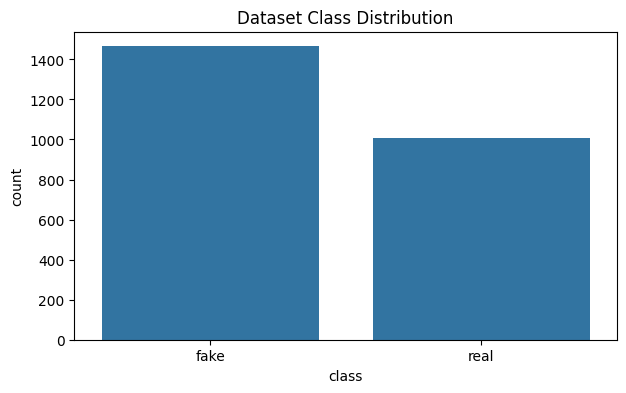

In [11]:
# ============================================================
# 7. DATASET AUDIT + IMAGE QUALITY CHECK
# ============================================================
def safe_image_info(path):
    try:
        with Image.open(path) as im:
            return im.size, im.mode
    except Exception:
        return None, None

sizes = []
modes = []
bad = []

for p in tqdm(df["path"], desc="Checking images"):
    size, mode = safe_image_info(p)
    if size is None:
        bad.append(p)
    else:
        sizes.append(size)
        modes.append(mode)

df["width"] = [x[0] for x in sizes] if sizes else []
df["height"] = [x[1] for x in sizes] if sizes else []

print("Unreadable:", len(bad))
print("Median width:", np.median(df["width"]))
print("Median height:", np.median(df["height"]))
print("Modes:")
print(pd.Series(modes).value_counts())

plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="class")
plt.title("Dataset Class Distribution")
plt.show()


## 4. Leakage-aware split

For a detector intended to generalize, a random split can be overly optimistic if identical or near-identical images occur in multiple partitions.

This notebook first removes exact byte duplicates and then performs a stratified train/validation/test split.

For a stronger publication-quality experiment, add generator IDs or source IDs if the dataset provides them. That is necessary for a true **unseen-generator-family** evaluation like the CVPR paper.


In [12]:
# ============================================================
# 8. EXACT-DUPLICATE REMOVAL + STRATIFIED SPLIT
# ============================================================
def file_md5(path, chunk=1024*1024):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(chunk)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

hashes = []
for p in tqdm(df["path"], desc="Hashing images"):
    try:
        hashes.append(file_md5(p))
    except Exception:
        hashes.append(None)

df["md5"] = hashes
before = len(df)
df = df.drop_duplicates("md5").reset_index(drop=True)
print("Removed exact duplicates:", before - len(df))

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", len(train_df))
print("Val  :", len(val_df))
print("Test :", len(test_df))

display(pd.DataFrame({
    "split": ["train", "validation", "test"],
    "real": [
        (train_df.label == 0).sum(),
        (val_df.label == 0).sum(),
        (test_df.label == 0).sum()
    ],
    "fake": [
        (train_df.label == 1).sum(),
        (val_df.label == 1).sum(),
        (test_df.label == 1).sum()
    ]
}))


Hashing images:   0%|          | 0/2470 [00:00<?, ?it/s]

Removed exact duplicates: 216
Train: 1577
Val  : 338
Test : 339


,split,real,fake
0,train,693,884
1,validation,149,189
2,test,149,190


In [13]:
# ============================================================
# 9. LOAD CLIP
# ============================================================
print("Loading:", CLIP_MODEL_ID)

processor = CLIPProcessor.from_pretrained(CLIP_MODEL_ID)
clip_model = CLIPModel.from_pretrained(CLIP_MODEL_ID)

clip_model = clip_model.to(DEVICE)
clip_model.eval()

for p in clip_model.parameters():
    p.requires_grad = False

# Infer embedding dimension
# Infer embedding dimension
with torch.no_grad():
    dummy = processor(
        images=Image.new("RGB", (224, 224), "gray"),
        return_tensors="pt"
    )
    dummy = {k: v.to(DEVICE) for k, v in dummy.items()}
    dummy_feat = clip_model.get_image_features(**dummy)
    if hasattr(dummy_feat, "pooler_output") and dummy_feat.pooler_output is not None:
        dummy_feat = dummy_feat.pooler_output
    elif hasattr(dummy_feat, "last_hidden_state"):
        dummy_feat = dummy_feat.last_hidden_state[:, 0, :]
    CLIP_DIM = int(dummy_feat.shape[-1])
print("Frozen CLIP embedding dimension:", CLIP_DIM)


Loading: openai/clip-vit-base-patch32


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

...

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Frozen CLIP embedding dimension: 512


## 5. Paper-faithful frozen CLIP detector

The paper maps each image to a fixed CLIP visual feature and does **not** fine-tune the CLIP encoder for the real-vs-fake task.

We implement:

- normalized CLIP embeddings
- nearest-neighbor classification using cosine distance
- k = 1, 3, 5, 9 voting
- a frozen-feature logistic/linear probe

The paper's exact primary backbone is ViT-L/14. If `CLIP_MODEL_ID` is changed to `openai/clip-vit-large-patch14`, this notebook uses that backbone.


In [17]:
# ============================================================
# 10. ROBUST IMAGE TRANSFORMS
# ============================================================
def jpeg_roundtrip(img, quality=75):
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=quality)
    buf.seek(0)
    return Image.open(buf).convert("RGB")

def paper_style_views(img):
    # The paper discusses Gaussian blur and JPEG compression
    # as important robustness augmentations.
    return [
        img.convert("RGB"),
        img.convert("RGB").filter(ImageFilter.GaussianBlur(radius=0.8)),
        jpeg_roundtrip(img.convert("RGB"), quality=75),
        img.convert("RGB").transpose(Image.Transpose.FLIP_LEFT_RIGHT),
    ]

def load_rgb(path):
    with Image.open(path) as im:
        return im.convert("RGB").copy()


In [19]:
# ============================================================
# 11. CLIP EMBEDDING EXTRACTION
# ============================================================
def clip_batch(images):
    inputs = processor(images=images, return_tensors="pt", padding=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        out = clip_model.get_image_features(**inputs)
        
        # Handle HuggingFace BaseModelOutputWithPooling vs raw Tensor
        if hasattr(out, "pooler_output") and out.pooler_output is not None:
            z = out.pooler_output
        elif hasattr(out, "last_hidden_state"):
            z = out.last_hidden_state[:, 0, :]
        elif hasattr(out, "image_embeds"):
            z = out.image_embeds
        else:
            z = out

        z = z.float()
        z = z / (z.norm(dim=-1, keepdim=True) + 1e-8)
    return z.cpu().numpy()

def extract_clip_features(paths, multiview=USE_MULTIVIEW):
    all_features = []

    for start in tqdm(range(0, len(paths), BATCH_SIZE), desc="CLIP embeddings"):
        batch_paths = paths[start:start+BATCH_SIZE]

        images = [load_rgb(p) for p in batch_paths]

        if not multiview:
            z = clip_batch(images)
            all_features.append(z)
            continue

        # Multi-view extension:
        # average normalized embeddings from original + blur + JPEG + flip.
        views = []
        for img in images:
            views.extend(paper_style_views(img))

        z_views = []
        for vstart in range(0, len(views), BATCH_SIZE):
            z_views.append(clip_batch(views[vstart:vstart+BATCH_SIZE]))

        z_views = np.concatenate(z_views, axis=0)
        z_views = z_views.reshape(len(images), 4, -1)

        mean_z = z_views.mean(axis=1)
        mean_z = mean_z / (np.linalg.norm(mean_z, axis=1, keepdims=True) + 1e-8)

        all_features.append(mean_z)

    return np.concatenate(all_features, axis=0).astype(np.float32)

def cache_name(split_name, multiview):
    safe = re.sub(r"[^A-Za-z0-9_.-]", "_", CLIP_MODEL_ID)
    return CACHE_DIR / f"{split_name}_{safe}_mv{int(multiview)}.npy"

def get_or_extract_clip(split_df, split_name):
    cp = cache_name(split_name, USE_MULTIVIEW)

    if cp.exists():
        print("Loading cache:", cp)
        return np.load(cp)

    z = extract_clip_features(split_df["path"].tolist(), USE_MULTIVIEW)
    np.save(cp, z)
    return z


In [20]:
# ============================================================
# 12. EXTRACT FROZEN CLIP FEATURES
# ============================================================
Z_train = get_or_extract_clip(train_df, "train")
Z_val   = get_or_extract_clip(val_df, "val")
Z_test  = get_or_extract_clip(test_df, "test")

y_train = train_df.label.to_numpy()
y_val   = val_df.label.to_numpy()
y_test  = test_df.label.to_numpy()

print(Z_train.shape, Z_val.shape, Z_test.shape)


CLIP embeddings:   0%|          | 0/395 [00:00<?, ?it/s]

CLIP embeddings:   0%|          | 0/85 [00:00<?, ?it/s]

CLIP embeddings:   0%|          | 0/85 [00:00<?, ?it/s]

(1577, 512) (338, 512) (339, 512)


In [22]:
# ============================================================
# 13. PAPER-STYLE NEAREST NEIGHBOR DETECTOR
# ============================================================
# Balance the feature bank so one class cannot dominate the NN bank.

def balanced_bank(Z, y, seed=SEED):
    rng = np.random.default_rng(seed)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    n = min(len(idx0), len(idx1))

    idx0 = rng.choice(idx0, n, replace=False)
    idx1 = rng.choice(idx1, n, replace=False)

    idx = np.concatenate([idx0, idx1])
    rng.shuffle(idx)
    return Z[idx], y[idx]

Z_bank, y_bank = balanced_bank(Z_train, y_train)

print("Balanced feature bank:", Z_bank.shape)
print("Real:", (y_bank == 0).sum(), "Fake:", (y_bank == 1).sum())

def knn_fake_probability(Z_query, Z_bank, y_bank, k=1):
    nn = NearestNeighbors(
        n_neighbors=k,
        metric="cosine",
        algorithm="brute"
    )
    nn.fit(Z_bank)

    distances, indices = nn.kneighbors(Z_query)

    # Convert cosine distance to similarity.
    similarities = 1.0 - distances

    probs = []
    for sims, inds in zip(similarities, indices):
        labels = y_bank[inds]
        # similarity-weighted vote
        weights = np.maximum(sims, 1e-6)
        probs.append(np.sum(weights * labels) / np.sum(weights))

    return np.asarray(probs)

knn_results = {}

for k in K_VALUES:
    p = knn_fake_probability(Z_test, Z_bank, y_bank, k=k)
    knn_results[k] = p

    print(
        f"k={k}: AP={average_precision_score(y_test,p):.4f}, "
        f"ROC-AUC={roc_auc_score(y_test,p):.4f}, "
        f"ACC={accuracy_score(y_test,p>=0.5):.4f}"
    )


Balanced feature bank: (1386, 512)
Real: 693 Fake: 693
k=1: AP=0.9458, ROC-AUC=0.9574, ACC=0.9587
k=3: AP=0.9843, ROC-AUC=0.9848, ACC=0.9617
k=5: AP=0.9942, ROC-AUC=0.9924, ACC=0.9587
k=9: AP=0.9963, ROC-AUC=0.9951, ACC=0.9646


In [23]:
# ============================================================
# 14. FROZEN-CLIP LINEAR PROBE
# ============================================================
# This trains ONLY a linear classifier on frozen CLIP features.
# The CLIP encoder remains untouched.

linear_probe = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED,
    solver="lbfgs"
)

linear_probe.fit(Z_train, y_train)

p_val_clip = linear_probe.predict_proba(Z_val)[:, 1]
p_test_clip = linear_probe.predict_proba(Z_test)[:, 1]

print("Validation AP:", average_precision_score(y_val, p_val_clip))
print("Test AP:", average_precision_score(y_test, p_test_clip))
print("Test ROC-AUC:", roc_auc_score(y_test, p_test_clip))


Validation AP: 0.9973932767434539
Test AP: 0.9977796544807598
Test ROC-AUC: 0.9971388202048745


## 6. New forensic feature branch

The paper shows that frequency artifacts can differ substantially between generative families. It also discusses co-occurrence-based and frequency-space baselines.

The following branch adds complementary, low-level features that are **not used to replace CLIP**, but are used to test whether combining broad semantic/perceptual features with image-forensic statistics improves this particular dataset.

### New feature groups

**Frequency**
- FFT radial spectrum
- high-pass residual
- DCT low/mid/high frequency energy

**Texture**
- LBP histogram
- GLCM contrast, dissimilarity, homogeneity, energy, correlation

**Image statistics**
- RGB/HSV moments
- gradient magnitude
- edge density
- Laplacian variance
- recompression response

These are deliberately separated from the paper-faithful CLIP-only experiment.


In [24]:
# ============================================================
# 15. FORENSIC FEATURE ENGINEERING
# ============================================================
def normalize_gray(gray):
    gray = gray.astype(np.float32)
    mn, mx = gray.min(), gray.max()
    return (gray - mn) / (mx - mn + 1e-8)

def resize_gray(img, size=256):
    arr = np.array(img.convert("L").resize((size, size), Image.Resampling.LANCZOS))
    return arr.astype(np.float32)

def fft_radial_features(gray, bins=16):
    g = gray.astype(np.float32)
    g = g - g.mean()

    F = np.fft.fftshift(np.fft.fft2(g))
    mag = np.log1p(np.abs(F))

    h, w = mag.shape
    yy, xx = np.ogrid[:h, :w]
    cy, cx = h/2, w/2
    radius = np.sqrt((yy-cy)**2 + (xx-cx)**2)
    radius = radius / radius.max()

    feats = []
    edges = np.linspace(0, 1, bins + 1)

    for i in range(bins):
        mask = (radius >= edges[i]) & (radius < edges[i+1])
        vals = mag[mask]
        feats.append(vals.mean() if vals.size else 0.0)

    return np.asarray(feats, dtype=np.float32)

def highpass_features(gray):
    g = gray.astype(np.float32)
    blur = cv2.GaussianBlur(g, (0,0), sigmaX=3)
    residual = g - blur

    return np.array([
        residual.mean(),
        residual.std(),
        np.mean(np.abs(residual)),
        np.percentile(np.abs(residual), 50),
        np.percentile(np.abs(residual), 90),
        np.percentile(np.abs(residual), 99),
        np.var(cv2.Laplacian(g, cv2.CV_32F))
    ], dtype=np.float32)

def dct_features(gray, size=32):
    g = cv2.resize(gray, (size, size)).astype(np.float32) / 255.0
    D = cv2.dct(g)

    yy, xx = np.indices(D.shape)
    low = (yy + xx <= 6)
    mid = (yy + xx > 6) & (yy + xx <= 16)
    high = (yy + xx > 16)

    energy = D**2

    return np.array([
        np.mean(energy[low]),
        np.mean(energy[mid]),
        np.mean(energy[high]),
        np.std(D),
        np.mean(np.abs(D))
    ], dtype=np.float32)

def lbp_features(gray, P=16, R=2):
    g = gray.astype(np.uint8)
    lbp = local_binary_pattern(g, P, R, method="uniform")
    n_bins = P + 2

    hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, n_bins + 1),
        density=True
    )
    return hist.astype(np.float32)

def glcm_features(gray):
    g = cv2.resize(gray, (128,128)).astype(np.uint8)
    # Quantize to 16 gray levels.
    q = (g // 16).astype(np.uint8)

    glcm = graycomatrix(
        q,
        distances=[1, 2],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=16,
        symmetric=True,
        normed=True
    )

    feats = []
    for prop in ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]:
        vals = graycoprops(glcm, prop)
        feats.extend([vals.mean(), vals.std()])

    return np.asarray(feats, dtype=np.float32)

def color_features(img):
    rgb = np.asarray(img.resize((128,128)).convert("RGB")).astype(np.float32) / 255.0
    hsv = cv2.cvtColor((rgb*255).astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)

    feats = []
    for arr in [rgb, hsv]:
        for c in range(3):
            x = arr[:,:,c].ravel()
            feats.extend([
                x.mean(), x.std(),
                np.percentile(x, 10),
                np.percentile(x, 50),
                np.percentile(x, 90)
            ])

    return np.asarray(feats, dtype=np.float32)

def edge_features(gray):
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)

    mag = np.sqrt(gx**2 + gy**2)
    edges = cv2.Canny(gray.astype(np.uint8), 100, 200)

    return np.array([
        mag.mean(),
        mag.std(),
        np.percentile(mag, 90),
        np.mean(edges > 0),
        np.var(gx),
        np.var(gy)
    ], dtype=np.float32)

def recompression_features(img):
    original = np.asarray(img.convert("RGB").resize((256,256))).astype(np.float32)

    vals = []
    for q in [50, 75, 90]:
        rec = jpeg_roundtrip(img, quality=q)
        rec = np.asarray(rec.resize((256,256))).astype(np.float32)

        diff = np.abs(original - rec)
        vals.extend([
            diff.mean(),
            diff.std(),
            np.percentile(diff, 90),
            np.percentile(diff, 99)
        ])

    return np.asarray(vals, dtype=np.float32)

def forensic_features(path):
    img = load_rgb(path)
    gray = resize_gray(img)

    features = np.concatenate([
        fft_radial_features(gray, bins=16),
        highpass_features(gray),
        dct_features(gray),
        lbp_features(gray),
        glcm_features(gray),
        color_features(img),
        edge_features(gray),
        recompression_features(img)
    ])

    return np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Test one image.
f0 = forensic_features(train_df.iloc[0].path)
print("Forensic feature dimension:", len(f0))


Forensic feature dimension: 104


In [25]:
# ============================================================
# 16. EXTRACT FORENSIC FEATURES
# ============================================================
def forensic_cache_name(split_name):
    return CACHE_DIR / f"{split_name}_forensics.npy"

def get_or_extract_forensics(split_df, split_name):
    cp = forensic_cache_name(split_name)

    if cp.exists():
        print("Loading:", cp)
        return np.load(cp)

    feats = []
    for p in tqdm(split_df["path"], desc=f"Forensic features [{split_name}]"):
        feats.append(forensic_features(p))

    feats = np.vstack(feats)
    np.save(cp, feats)
    return feats

F_train = get_or_extract_forensics(train_df, "train")
F_val   = get_or_extract_forensics(val_df, "val")
F_test  = get_or_extract_forensics(test_df, "test")

print("Forensic shapes:", F_train.shape, F_val.shape, F_test.shape)


Forensic features [train]:   0%|          | 0/1577 [00:00<?, ?it/s]

Forensic features [val]:   0%|          | 0/338 [00:00<?, ?it/s]

Forensic features [test]:   0%|          | 0/339 [00:00<?, ?it/s]

Forensic shapes: (1577, 104) (338, 104) (339, 104)


## 7. Feature fusion

The proposed extension combines:

```text
CLIP feature vector
        +
Forensic vector
        ↓
standardize forensic branch
        ↓
weighted concatenation
        ↓
linear probe
```

The CLIP branch remains frozen. Only the final classifier is trained.

This is **not claimed to be the exact Ojha et al. model**. It is the proposed extension built around the paper's universal-feature-space idea.


In [26]:
# ============================================================
# 17. CLIP + FORENSIC FEATURE FUSION
# ============================================================
forensic_scaler = StandardScaler()
F_train_s = forensic_scaler.fit_transform(F_train)
F_val_s   = forensic_scaler.transform(F_val)
F_test_s  = forensic_scaler.transform(F_test)

# Weight controls the influence of handcrafted forensic features.
FORENSIC_WEIGHT = 0.25

H_train = np.hstack([
    Z_train,
    F_train_s * FORENSIC_WEIGHT
]).astype(np.float32)

H_val = np.hstack([
    Z_val,
    F_val_s * FORENSIC_WEIGHT
]).astype(np.float32)

H_test = np.hstack([
    Z_test,
    F_test_s * FORENSIC_WEIGHT
]).astype(np.float32)

print("Hybrid feature dimensions:", H_train.shape)

hybrid_probe = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED,
    solver="lbfgs"
)

hybrid_probe.fit(H_train, y_train)

p_val_hybrid = hybrid_probe.predict_proba(H_val)[:,1]
p_test_hybrid = hybrid_probe.predict_proba(H_test)[:,1]

print("Hybrid test AP:", average_precision_score(y_test, p_test_hybrid))
print("Hybrid test ROC-AUC:", roc_auc_score(y_test, p_test_hybrid))


Hybrid feature dimensions: (1577, 616)
Hybrid test AP: 0.9997281188445629
Hybrid test ROC-AUC: 0.9996467679265277


In [28]:
# ============================================================
# 18. VALIDATION-ONLY THRESHOLD CALIBRATION
# ============================================================
def best_threshold(y_true, prob):
    thresholds = np.linspace(0.05, 0.95, 181)
    scores = []

    for t in thresholds:
        pred = (prob >= t).astype(int)
        scores.append(accuracy_score(y_true, pred))

    i = int(np.argmax(scores))
    return float(thresholds[i]), float(scores[i])

clip_threshold, clip_val_acc = best_threshold(y_val, p_val_clip)
hybrid_threshold, hybrid_val_acc = best_threshold(y_val, p_val_hybrid)

print("CLIP threshold:", clip_threshold, "validation accuracy:", clip_val_acc)
print("Hybrid threshold:", hybrid_threshold, "validation accuracy:", hybrid_val_acc)


CLIP threshold: 0.4499999999999999 validation accuracy: 0.9792899408284024
Hybrid threshold: 0.4599999999999999 validation accuracy: 0.9970414201183432


In [29]:
# ============================================================
# 19. EVALUATION UTILITIES
# ============================================================
def evaluate_binary(y_true, prob, threshold=0.5, name="Model"):
    pred = (prob >= threshold).astype(int)

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, prob),
        "average_precision": average_precision_score(y_true, prob),
    }

    print(pd.Series(metrics))
    print("\nClassification report:")
    print(classification_report(
        y_true, pred,
        target_names=["Real", "Fake"],
        zero_division=0
    ))

    return metrics

results = []

results.append(evaluate_binary(
    y_test, p_test_clip, clip_threshold,
    "Ojha-style Frozen CLIP + Linear Probe"
))

results.append(evaluate_binary(
    y_test, knn_results[1], 0.5,
    "Frozen CLIP + NN (k=1)"
))

results.append(evaluate_binary(
    y_test, knn_results[9], 0.5,
    "Frozen CLIP + NN (k=9)"
))

results.append(evaluate_binary(
    y_test, p_test_hybrid, hybrid_threshold,
    "Proposed Hybrid CLIP + Forensics"
))

results_df = pd.DataFrame(results)
display(results_df)


model                Ojha-style Frozen CLIP + Linear Probe
accuracy                                          0.976401
precision                                         0.973958
recall                                            0.984211
f1                                                0.979058
roc_auc                                           0.997139
average_precision                                  0.99778
dtype: object

Classification report:
              precision    recall  f1-score   support

        Real       0.98      0.97      0.97       149
        Fake       0.97      0.98      0.98       190

    accuracy                           0.98       339
   macro avg       0.98      0.98      0.98       339
weighted avg       0.98      0.98      0.98       339

model                Frozen CLIP + NN (k=1)
accuracy                           0.958702
precision                          0.958333
recall                             0.968421
f1                                 0.963351
ro

,model,accuracy,precision,recall,f1,roc_auc,average_precision
0,Ojha-style Frozen CLIP + Linear Probe,0.976401,0.973958,0.984211,0.979058,0.997139,0.997780
1,Frozen CLIP + NN (k=1),0.958702,0.958333,0.968421,0.963351,0.957365,0.945769
2,Frozen CLIP + NN (k=9),0.964602,0.968421,0.968421,0.968421,0.995090,0.996344
3,Proposed Hybrid CLIP + Forensics,0.988201,0.989474,0.989474,0.989474,0.999647,0.999728


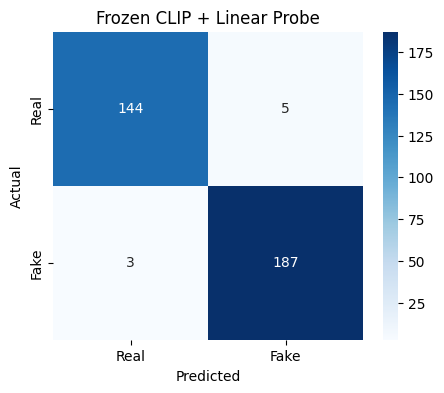

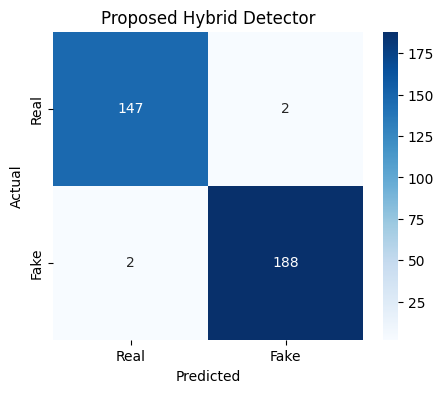

In [30]:
# ============================================================
# 20. CONFUSION MATRICES
# ============================================================
def show_cm(y_true, prob, threshold, title):
    pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Real","Fake"],
        yticklabels=["Real","Fake"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

show_cm(
    y_test, p_test_clip, clip_threshold,
    "Frozen CLIP + Linear Probe"
)

show_cm(
    y_test, p_test_hybrid, hybrid_threshold,
    "Proposed Hybrid Detector"
)


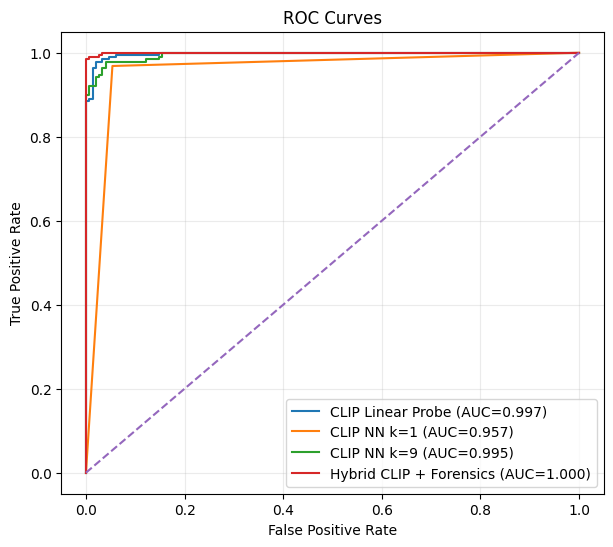

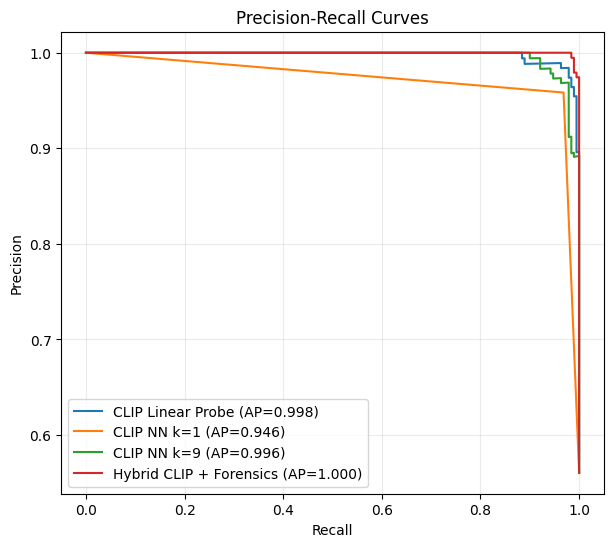

In [31]:
# ============================================================
# 21. ROC + PRECISION-RECALL CURVES
# ============================================================
models_to_plot = {
    "CLIP Linear Probe": p_test_clip,
    "CLIP NN k=1": knn_results[1],
    "CLIP NN k=9": knn_results[9],
    "Hybrid CLIP + Forensics": p_test_hybrid,
}

plt.figure(figsize=(7,6))
for name, prob in models_to_plot.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(7,6))
for name, prob in models_to_plot.items():
    precision, recall, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    plt.plot(recall, precision, label=f"{name} (AP={ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 8. Frequency-domain analysis from the paper

The paper explicitly investigates high-frequency residuals by subtracting a blurred image and then computing the Fourier transform. It shows that some GAN families have recurring frequency fingerprints while diffusion images can have a different frequency behavior.

The following visualization reproduces that **analysis idea** for your Kaggle dataset, without claiming that the Kaggle classes correspond to the paper's exact generator families.


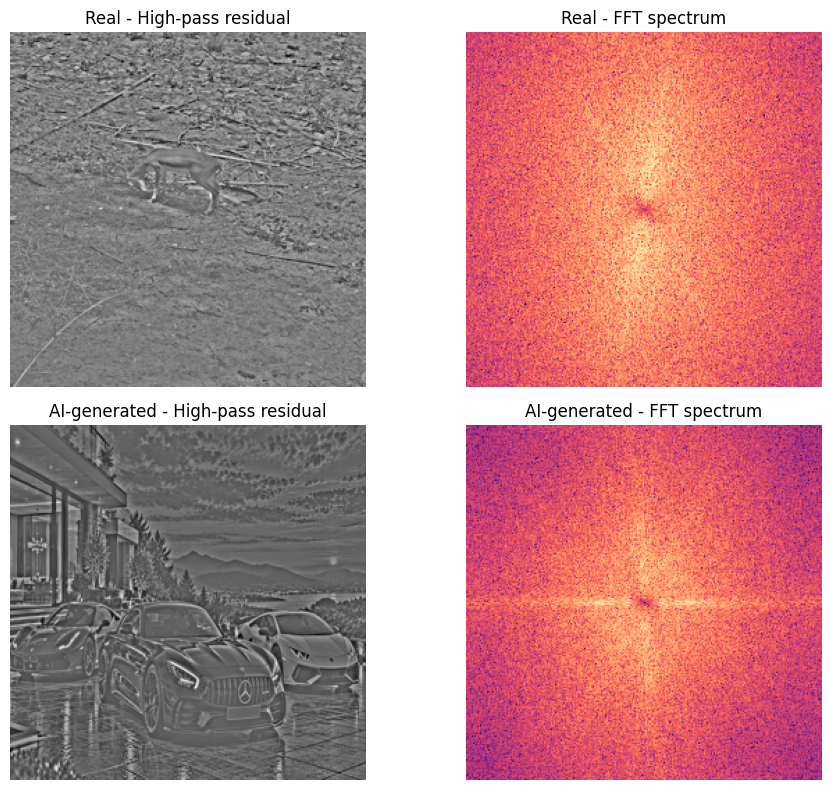

In [32]:
# ============================================================
# 22. FREQUENCY SPECTRUM VISUALIZATION
# ============================================================
def highpass_fft_image(path):
    img = load_rgb(path)
    gray = np.asarray(img.resize((256,256)).convert("L")).astype(np.float32)

    blur = cv2.GaussianBlur(gray, (0,0), 3)
    residual = gray - blur

    F = np.fft.fftshift(np.fft.fft2(residual))
    spectrum = np.log1p(np.abs(F))

    return residual, spectrum

real_path = train_df[train_df.label == 0].iloc[0].path
fake_path = train_df[train_df.label == 1].iloc[0].path

fig, ax = plt.subplots(2, 2, figsize=(10,8))

for row, (path, label) in enumerate([
    (real_path, "Real"),
    (fake_path, "AI-generated")
]):
    residual, spectrum = highpass_fft_image(path)

    ax[row,0].imshow(residual, cmap="gray")
    ax[row,0].set_title(f"{label} - High-pass residual")
    ax[row,0].axis("off")

    ax[row,1].imshow(spectrum, cmap="magma")
    ax[row,1].set_title(f"{label} - FFT spectrum")
    ax[row,1].axis("off")

plt.tight_layout()
plt.show()


## 9. t-SNE visualization of the frozen feature space

The paper uses t-SNE to inspect whether real/fake distributions form separable structures in different pretrained feature spaces.

We do the same analysis with the frozen CLIP embeddings from this dataset.


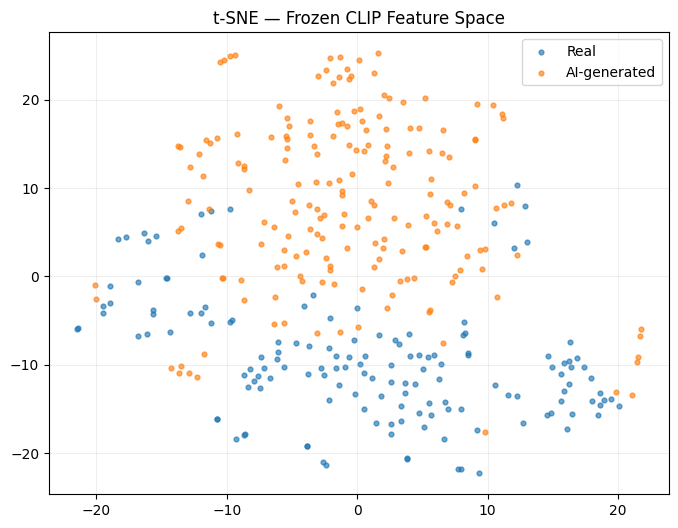

In [33]:
# ============================================================
# 23. t-SNE OF FROZEN CLIP FEATURES
# ============================================================
N_TSNE = min(1500, len(Z_test))

rng = np.random.default_rng(SEED)
idx = rng.choice(len(Z_test), N_TSNE, replace=False)

Z_small = Z_test[idx]
y_small = y_test[idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=SEED,
    init="pca",
    learning_rate="auto"
)

Z_2d = tsne.fit_transform(Z_small)

plt.figure(figsize=(8,6))
plt.scatter(
    Z_2d[y_small == 0, 0],
    Z_2d[y_small == 0, 1],
    s=12, alpha=0.65, label="Real"
)
plt.scatter(
    Z_2d[y_small == 1, 0],
    Z_2d[y_small == 1, 1],
    s=12, alpha=0.65, label="AI-generated"
)

plt.title("t-SNE — Frozen CLIP Feature Space")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 10. Robustness / domain-shift test

A true unseen-generator test requires generator-labeled data. The supplied Kaggle dataset may not expose those labels.

As a practical additional experiment, we create controlled versions of the test images using:

- JPEG quality 50
- JPEG quality 75
- Gaussian blur
- mild resizing

This tests whether the detector is excessively dependent on the original image encoding.

This is a **robustness test, not a replacement for unseen-generator evaluation**.


In [34]:
# ============================================================
# 24. ROBUSTNESS TEST
# ============================================================
def transform_image(img, mode):
    if mode == "jpeg50":
        return jpeg_roundtrip(img, 50)
    if mode == "jpeg75":
        return jpeg_roundtrip(img, 75)
    if mode == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=1.2))
    if mode == "resize":
        small = img.resize((128,128), Image.Resampling.BILINEAR)
        return small.resize((224,224), Image.Resampling.BILINEAR)
    return img

def extract_clip_single_view(images):
    out = []
    for start in range(0, len(images), BATCH_SIZE):
        out.append(clip_batch(images[start:start+BATCH_SIZE]))
    return np.vstack(out)

def robustness_clip_predictions(paths, modes):
    predictions = {}

    base_images = [load_rgb(p) for p in paths]

    for mode in modes:
        imgs = [transform_image(img, mode) for img in base_images]
        z = extract_clip_single_view(imgs)
        predictions[mode] = linear_probe.predict_proba(z)[:,1]

    return predictions

ROBUSTNESS_N = min(500, len(test_df))
robust_paths = test_df.iloc[:ROBUSTNESS_N]["path"].tolist()
robust_y = test_df.iloc[:ROBUSTNESS_N]["label"].to_numpy()

robust_pred = robustness_clip_predictions(
    robust_paths,
    ["original", "jpeg50", "jpeg75", "blur", "resize"]
) if False else None

# Build the original explicitly because "original" needs no transform.
robust_pred = {}
base_imgs = [load_rgb(p) for p in robust_paths]

for mode in ["original", "jpeg50", "jpeg75", "blur", "resize"]:
    imgs = [img if mode == "original" else transform_image(img, mode)
            for img in base_imgs]

    z = extract_clip_single_view(imgs)
    robust_pred[mode] = linear_probe.predict_proba(z)[:,1]

robust_rows = []
for mode, prob in robust_pred.items():
    robust_rows.append({
        "condition": mode,
        "accuracy@validation-threshold": accuracy_score(
            robust_y, (prob >= clip_threshold).astype(int)
        ),
        "AP": average_precision_score(robust_y, prob),
        "ROC-AUC": roc_auc_score(robust_y, prob)
    })

robust_df = pd.DataFrame(robust_rows)
display(robust_df)


,condition,accuracy@validation-threshold,AP,ROC-AUC
0,original,0.976401,0.997660,0.996927
1,jpeg50,0.973451,0.997252,0.996432
2,jpeg75,0.976401,0.997826,0.997068
3,blur,0.970501,0.997200,0.996432
4,resize,0.970501,0.994727,0.993006


## 11. Ablation study

For a research report, do not only report the final model.

Compare:

1. **Frozen CLIP + NN** — paper-style baseline.
2. **Frozen CLIP + linear probe** — paper-style baseline.
3. **Forensic-only linear model** — added feature branch.
4. **CLIP + forensic fusion** — proposed extension.

The ablation shows which feature groups actually contribute on your dataset.


In [37]:
# ============================================================
# 25. FORENSIC-ONLY ABLATION
# ============================================================
forensic_only_probe = LogisticRegression(
    max_iter=3000,
    class_weight="balanced",
    random_state=SEED
)

forensic_only_probe.fit(F_train_s, y_train)
p_test_forensic = forensic_only_probe.predict_proba(F_test_s)[:,1]

forensic_threshold, forensic_val_acc = best_threshold(
    y_val,
    forensic_only_probe.predict_proba(F_val_s)[:,1]
)

ablation = [
    {
        "model": "Frozen CLIP + NN (k=1)",
        "AP": average_precision_score(y_test, knn_results[1]),
        "Accuracy": accuracy_score(y_test, knn_results[1] >= 0.5),
        "ROC-AUC": roc_auc_score(y_test, knn_results[1])
    },
    {
        "model": "Frozen CLIP + Linear Probe",
        "AP": average_precision_score(y_test, p_test_clip),
        "Accuracy": accuracy_score(y_test, p_test_clip >= clip_threshold),
        "ROC-AUC": roc_auc_score(y_test, p_test_clip)
    },
    {
        "model": "Forensic-only",
        "AP": average_precision_score(y_test, p_test_forensic),
        "Accuracy": accuracy_score(y_test, p_test_forensic >= forensic_threshold),
        "ROC-AUC": roc_auc_score(y_test, p_test_forensic)
    },
    {
        "model": "Proposed CLIP + Forensic Fusion",
        "AP": average_precision_score(y_test, p_test_hybrid),
        "Accuracy": accuracy_score(y_test, p_test_hybrid >= hybrid_threshold),
        "ROC-AUC": roc_auc_score(y_test, p_test_hybrid)
    }
]

ablation_df = pd.DataFrame(ablation)
display(ablation_df.sort_values("AP", ascending=False))


,model,AP,Accuracy,ROC-AUC
3,Proposed CLIP + Forensic Fusion,0.999728,0.988201,0.999647
1,Frozen CLIP + Linear Probe,0.997780,0.976401,0.997139
2,Forensic-only,0.994173,0.964602,0.991946
0,Frozen CLIP + NN (k=1),0.945769,0.958702,0.957365


In [40]:
# ============================================================
# 26. SAVE MODELS + ARTIFACTS
# ============================================================
import joblib

ARTIFACT_DIR = Path("./deepfake_universal_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

joblib.dump(linear_probe, ARTIFACT_DIR / "clip_linear_probe.joblib")
joblib.dump(hybrid_probe, ARTIFACT_DIR / "clip_forensic_hybrid_probe.joblib")
joblib.dump(forensic_only_probe, ARTIFACT_DIR / "forensic_only_probe.joblib")
joblib.dump(forensic_scaler, ARTIFACT_DIR / "forensic_scaler.joblib")

np.save(ARTIFACT_DIR / "clip_threshold.npy", np.array([clip_threshold]))
np.save(ARTIFACT_DIR / "hybrid_threshold.npy", np.array([hybrid_threshold]))

config = {
    "clip_model_id": CLIP_MODEL_ID,
    "clip_dim": CLIP_DIM,
    "image_size": IMAGE_SIZE,
    "multiview": USE_MULTIVIEW,
    "forensic_weight": FORENSIC_WEIGHT,
    "k_values": K_VALUES,
    "seed": SEED
}

with open(ARTIFACT_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved artifacts to:", ARTIFACT_DIR.resolve())


Saved artifacts to: /kaggle/working/deepfake_universal_artifacts


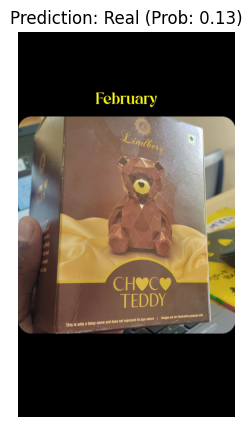

{'image': '/kaggle/input/datasets/rohithsaikambhampati/ai-generated-vs-real-images-dataset/REAL-20261001T063914Z-1-001/REAL/Snapchat-1858062383.jpg', 'clip_fake_probability': 0.18027041203430288, 'clip_prediction': 'Real', 'hybrid_fake_probability': 0.12884939191460332, 'hybrid_prediction': 'Real'}


In [44]:
# ============================================================
# 27. SINGLE-IMAGE PREDICTION
# ============================================================
def predict_image(path):
    img = load_rgb(path)

    # Frozen CLIP feature
    z = clip_batch([img])

    # CLIP probability
    p_clip = float(linear_probe.predict_proba(z)[0, 1])

    # Forensic branch
    f = forensic_features(path).reshape(1, -1)
    f_s = forensic_scaler.transform(f)

    h = np.hstack([z, f_s * FORENSIC_WEIGHT]).astype(np.float32)
    p_hybrid = float(hybrid_probe.predict_proba(h)[0, 1])

    result = {
        "image": str(path),
        "clip_fake_probability": p_clip,
        "clip_prediction": "AI-generated" if p_clip >= clip_threshold else "Real",
        "hybrid_fake_probability": p_hybrid,
        "hybrid_prediction": "AI-generated" if p_hybrid >= hybrid_threshold else "Real",
    }
    return result


# --- Display Image + Prediction ---
example_path = test_df.iloc[0].path
res = predict_image(example_path)

# Show image with prediction in title
img = load_rgb(example_path)
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {res['hybrid_prediction']} (Prob: {res['hybrid_fake_probability']:.2f})")
plt.axis("off")
plt.show()

# Print full dictionary output
print(res)

## 12. Optional exact-paper backbone run

For the final experiment, change:

```python
CLIP_MODEL_ID = "openai/clip-vit-large-patch14"
```

and restart the runtime before rerunning the model-loading and feature-extraction cells.

The CVPR paper specifically uses **CLIP ViT-L/14** and reports a 768-dimensional visual feature. The paper's ablation also indicates that CLIP-pretraining and the diversity of the pretraining data matter strongly, not merely the backbone architecture.

If GPU memory is insufficient, keep `openai/clip-vit-base-patch32` for development and clearly report that it is an implementation variant rather than the exact ViT-L/14 configuration.


# 13. Research-report methodology

## Proposed architecture

```text
                    INPUT IMAGE
                         │
          ┌──────────────┴──────────────┐
          │                             │
     Frozen CLIP                  Forensic branch
   visual encoder                (new extension)
          │                             │
          │                    ┌────────┼────────┐
          │                    │        │        │
          │                   FFT     DCT      Texture
          │                    │        │        │
          │                   HP      LBP      GLCM
          │                    │        │        │
          │                   Color   Edges   Recompression
          │                    └────────┼────────┘
          │                             │
          └──────────────┬──────────────┘
                         │
                  FEATURE FUSION
                         │
                   LINEAR PROBE
                         │
                  REAL / AI-FAKE
```

## What is directly based on Ojha et al.

- frozen pretrained visual feature space
- CLIP visual encoder
- cosine-distance nearest neighbor
- k-nearest-neighbor voting
- linear probing
- validation-based threshold selection
- t-SNE feature-space inspection
- robustness/generalization motivation
- emphasis on unseen generative-model generalization

## What is newly added in this notebook

- multi-view CLIP embedding
- JPEG + Gaussian-blur + flip feature views
- FFT radial spectrum
- high-pass residual statistics
- DCT statistics
- LBP
- GLCM/co-occurrence features
- color statistics
- edge statistics
- recompression response
- CLIP + forensic feature fusion
- forensic-only ablation
- controlled corruption robustness evaluation

## What you should NOT claim

Do not write that this notebook reproduces the CVPR paper's exact benchmark unless you run the original benchmark datasets and unseen generator splits.

Do not claim that the Kaggle dataset proves generalization to unseen GAN/diffusion/autoregressive families unless generator identities are available and the test set is explicitly held out by generator family.

For your project, a scientifically defensible claim is:

> "We implement the frozen pretrained feature-space detection paradigm motivated by Ojha et al. and extend it with complementary frequency, texture, residual, recompression and multi-view features for the AI-generated-vs-real Kaggle dataset."


# 14. Recommended experiments for your final submission

### Experiment A — Paper-faithful baseline
Frozen CLIP → NN (k=1/3/5/9)

### Experiment B — Paper-faithful linear probe
Frozen CLIP → Logistic/Linear classifier

### Experiment C — New forensic baseline
FFT + DCT + LBP + GLCM + residual + color + edge + recompression → linear classifier

### Experiment D — Proposed model
Frozen CLIP + forensic features → linear probe

### Experiment E — Robustness
Original vs JPEG50 vs JPEG75 vs blur vs resize

### Experiment F — Exact-paper configuration
Repeat A/B using:

```text
openai/clip-vit-large-patch14
```

### Final table

| Experiment | Feature space | Encoder trained? | AP | Accuracy | ROC-AUC |
|---|---|---:|---:|---:|---:|
| A | Frozen CLIP + NN | No | fill after run | fill | fill |
| B | Frozen CLIP + Linear | No | fill after run | fill | fill |
| C | Forensic features | No | fill after run | fill | fill |
| D | CLIP + Forensics | No CLIP fine-tuning | fill after run | fill | fill |
| E | Robustness | No | fill after run | fill | fill |

This gives you a clean experimental story: **paper method → added forensic features → hybrid model → robustness analysis**.


# References

1. Utkarsh Ojha, Yuheng Li, Yong Jae Lee. **Towards Universal Fake Image Detectors that Generalize Across Generative Models.** CVPR 2023.
2. Kaggle: **AI GENERATED vs REAL IMAGES Dataset** — `rohithsaikambhampati/ai-generated-vs-real-images-dataset`.

### Paper implementation note

The CVPR paper reports that a frozen CLIP feature space with nearest-neighbor and linear-probe classification generalizes better to unseen generative-model families than task-trained deep classifiers. It also studies the effect of frequency artifacts, backbone architecture and pretraining data.

This notebook preserves that central idea and adds the forensic feature branch as a separate, testable extension.
